# 0.Prerequisite

## 0.1.LROSE-Core installation

### 0.1.1. Install LROSE-CORE from package

>Create section for collapsible

In [1]:
!lsb_release -a

No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 22.04.3 LTS
Release:	22.04
Codename:	jammy


In [2]:
!curl -LO https://github.com/NCAR/lrose-core/releases/download/lrose-core-20230814/lrose-core-20230814.ubuntu_22.04.amd64.deb \
    && apt install -y ./lrose-core-20230814.ubuntu_22.04.amd64.deb

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 35.5M  100 35.5M    0     0  25.4M      0  0:00:01  0:00:01 --:--:-- 80.0M
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'lrose-core' instead of './lrose-core-20230814.ubuntu_22.04.amd64.deb'
The following additional packages will be installed:
  flex hdf5-tools libegl-dev libeigen3-dev libevdev2 libfftw3-bin libfftw3-dev libfftw3-double3
  libfftw3-long3 libfftw3-quad3 libfftw3-single3 libfl-dev libfl2 libgl-dev libglu1-mesa
  libglu1-mesa-dev libglx-dev libgudev-1.0-0 libinput-bin libinput10 libmd4c0 libmtdev1
  libqt5concurrent5 libqt5core5a libqt5dbus5 libqt5gui5 libqt5network5 libqt5opengl5
  libqt5opengl5-dev libqt5printsupport5 libqt5qml5 libqt5qmlmodels5 libqt5qmlworkerscript

### 0.1.2. Set environment path

In [3]:
import os

added_lrose_env_path = os.environ['PATH'] + ":/usr/local/lrose/bin"
added_ld_library_path = os.environ['LD_LIBRARY_PATH'] + ":/usr/local/lrose/lib"

%env PATH=$added_lrose_env_path
%env LD_LIBRARY_PATH=$added_ld_library_path

env: PATH=/opt/bin:/usr/local/nvidia/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin:/usr/local/lrose/bin
env: LD_LIBRARY_PATH=/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/lrose/lib


### 0.1.3. Test installation

In [4]:
# If shown, then it means installation is success
!RadxPrint -h

Usage: RadxPrint [args as below]
Options:

  [ -h ] produce this list.

  [ -ag ] aggregate sweep files into volume on read
          applies to DORADE and CFRADIAL sweep files

  [ -ag_all ] aggregate files in input list on read.
          ALL FILES in the input list are aggregated into a volume.
          See '-f' option.

  [ -ang ? ] set single fixed angle
             or minimum - see '-ang_max'

  [ -ang_max ? ] set max fixed angle
                 use '-ang' for setting minimum

  [ -apply_georefs] apply georeference corrections on read.
      For moving platforms, measured georeference information is
      somtimes available.
      If so, this is applied and appropriate corrections made.
      Earth-centric azimuth and elevation angles will be computed.

  [ -change_lat_sign] change the sign of the radar latitude
    Useful for RAPIC files that always have a positive latitude.

  [ -const_ngates ] force number of gates constant for all rays
                    Added gates will 

## 0.2.Setup environment


### 0.2.1.Install Python libraries

In [5]:
!pip install numpy scipy matplotlib netcdf4 wradlib cartopy arm_pyart xarray xradar

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.5/232.5 kB 23.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 50.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 45.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.3/91.3 kB 13.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.3/63.3 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 21.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 92.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.6.0
    Uninstalling fsspec-2023.6.

### 0.2.2.Import Python libraries

In [6]:
import os
import netCDF4 as nc
import xml.etree.ElementTree as ET
import json

# Working with directory
import pathlib

import pyart


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

0.3.0


### 0.2.3.Supporting methods

In [7]:
# Function to check if a file is a valid NetCDF file
def is_netcdf_file(file_path):
    try:
        nc_file = nc.Dataset(file_path, 'r')
        nc_file.close()
        return True
    except Exception:
        return False

In [8]:
# Function to export NetCDF content to XML
def export_to_xml(nc_file, xml_folder):
    root = ET.Element('NetCDFData')
    for var_name in nc_file.variables:
        variable = nc_file.variables[var_name]
        var_element = ET.SubElement(root, 'Variable', name=var_name)
        for attr_name in variable.ncattrs():
            attr_element = ET.SubElement(var_element, 'Attribute', name=attr_name)
            attr_element.text = str(getattr(variable, attr_name))
        data_element = ET.SubElement(var_element, 'Data')
        data_element.text = str(variable[:])

    xml_file = os.path.join(xml_folder, os.path.basename(nc_file.filepath()) + '.xml')
    tree = ET.ElementTree(root)
    tree.write(xml_file)

In [9]:
# Function to export NetCDF content to JSON
def export_to_json(nc_file, json_folder):
    data = {}
    for var_name in nc_file.variables:
        variable = nc_file.variables[var_name]
        data[var_name] = variable[:].tolist()

    json_file = os.path.join(json_folder, os.path.basename(nc_file.filepath()) + '.json')
    with open(json_file, 'w') as jf:
        json.dump(data, jf, indent=4)

In [10]:
# Function to find the first valid NetCDF file in a directory and its subdirectories
def find_first_valid_netcdf(directory_path):
    for root, dirs, files in os.walk(directory_path):
        for file in files:
            file_path = os.path.join(root, file)
            if is_netcdf_file(file_path):
                return file_path
    return None

## 0.3.Import dataset

### 0.1.1.Mounting Drive

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
!cp ./drive/MyDrive/WeatherDataset/raw/20190510_231241_nha-be-r_v001_SUR.uf ./data.uf

cp: cannot stat './drive/MyDrive/dataset/raw/20190510_231241_nha-be-r_v001_SUR.uf': No such file or directory


In [ ]:
!ln -s /content/drive/MyDrive/WeatherDataset/ /content/WeatherDataset

# 1.Data Understanding

## 1.0.Investigate LROSE tools

### 1.1.1.RadxPrint on REAL UF file

In [ ]:
!ls /usr/b

bin  colab  games  grte  include  lib  lib32  lib64  libexec  libx32  local  sbin  share  src


In [ ]:
!RadxPrint -v -f ./drive/MyDrive/WeatherDataset/20190510_231241_nha-be-r_v001_SUR.uf

Working on file: ./drive/MyDrive/WeatherDataset/20190510_231241_nha-be-r_v001_SUR.uf
======= RadxFile read request =======
  debug: Y
  verbose: N
  readIgnoreIdleMode: N
  readIgnoreTransitions: N
  readTransitionNraysMargin: 0
  readAggregateSweeps: N
  readRemoveRaysAllMissing: N
  readRemoveLongRange: N
  readRemoveShortRange: N
End of file
INFO: RadxFile::readFromPath
  Read UF file, path: ./drive/MyDrive/WeatherDataset/20190510_231241_nha-be-r_v001_SUR.uf
  ==>> read in file: ./drive/MyDrive/WeatherDataset/20190510_231241_nha-be-r_v001_SUR.uf
=============== RadxVol ===============
  convention: 
  version: 
  title: NB2
  institution: 
  references: Conversi
  source: Sigmet I
  history: 20190510_231241_nha-be-r_v001_SUR.uf
  comment: 
  volNum: 1
  scanName: 
  scanId(VCP): 0
--------------- RadxPlatform ---------------
  instrumentName: nha-be-r
  siteName: nha-be-r
  instrumentType: radar
  platformType: fixed
  primaryAxis: axis_z
  latitudeDeg: 10.6596
  longitudeDeg: 106.7

### 1.1.2.RadxPrint on PROVIDED UF file

In [ ]:
!RadxPrint -v -f ./drive/MyDrive/WeatherDataset/NHB190510231240.uf

Working on file: ./drive/MyDrive/WeatherDataset/NHB190510231240.uf
======= RadxFile read request =======
  debug: Y
  verbose: N
  readIgnoreIdleMode: N
  readIgnoreTransitions: N
  readTransitionNraysMargin: 0
  readAggregateSweeps: N
  readRemoveRaysAllMissing: N
  readRemoveLongRange: N
  readRemoveShortRange: N
Note: byte swapping is not needed for this file
============== summary so far ===============
  pulseWidthUs: 0.8
  wavelengthCm: 5.36
  wavelengthM: 0.0536
  prf: 1180
  prtSec: 0.000847458
  nyquist: 63.248
  unambigRangeKm: 127.031
  nbytesExtendedHdr: -12
  sigmetIsSwapped: N
Found the following fields: 
  fieldId, name, units, byteWidth, scale, bias: 8, DBZ_TOT, dBZ, 2, 0.01, -327.68
Found the following fields: 
  fieldId, name, units, byteWidth, scale, bias: 9, DBZ, dBZ, 2, 0.01, -327.68
Found the following fields: 
  fieldId, name, units, byteWidth, scale, bias: 10, VEL, m/s, 2, 0.01, -327.68
Found the following fields: 
  fieldId, name, units, byteWidth, scale, bias:

## 1.1.The Universal Format

### Overview
UF, shorts for Universal Format, is a common data format for storing data in various radar technologies. Formally, it is also known as *Common Doppler Radar Exchange Format*.

At first, UF was designed to access by FORTRAN. According to the documentation (see [Barnes, Stanley L, 1980](https://www.eol.ucar.edu/sites/default/files/files_live/private/UfDoc.txt)), some of the notable specifications include:

- 9 track tapes, 1600 or 6250 cpi density.
- 16-bit words, signed integers, 2's complement.
- Physical records, length <= 4095 words.

### LROSE supports
UF is one of the formats the is currently supported by the LROSE tools. For instance, below is the window of an UF file from the given data of Nha Be's radar.


![HawkEye](https://kyletran-cse-hcmut.notion.site/image/https%3A%2F%2Fprod-files-secure.s3.us-west-2.amazonaws.com%2F6f431e95-8f27-48e6-a11e-ca92c46ad5ef%2F31d63339-c9d0-4fcb-857f-164ba1b5dafb%2FRadxPrint_UF.png?table=block&id=878af98f-f5a1-4890-bcc5-d67eeb37dd8a&spaceId=6f431e95-8f27-48e6-a11e-ca92c46ad5ef&width=2000&userId=&cache=v2)

**Note:** Also in the given data file, files with extension type of `*.RAW*` is just the UF file with the same name. We can verify that by using the `cmp` tool:

```bash
cmp --verbose NHB190510231240.RAW97JC NHB190510231240.uf
```

Returning no result means these two files are exactly identical.

### Technical details
Despite its popularity, details about this type of format is very limited. In fact, the only paper that our team can find is from [NCAR's LROSE-supported data formats in radial coordinates](https://www.eol.ucar.edu/content/standard-data-formats). Moreover, we cannot sure that the given `*.UF` files really follow the pre-defined rules.

Some of this data format elements are:
- **Endianess**: Big-endian
- **Supported Radar Data**:
    - Reflectivity and Relative reflectivity
    - Velocity
    - Spectral width
    - ...
- **Coordinate system**: Native polar coordinates


Each file is a snapshot in time, with a frequency of 5 minutes between each execution. However, each scan may take up to 1 minute for a full picture.


In [13]:
import os
import pyart
import matplotlib.pyplot as plt

In [14]:
# Replace 'your_radar_data_file' with the path to your radar data file (in a supported format).
radar_data_file = 'data.uf'

# Load the radar data from the file
radar = pyart.io.read(radar_data_file)

# Create a display object for the radar data
display = pyart.graph.RadarDisplay(radar)

# Plot reflectivity data
fig = plt.figure(figsize=[10, 8])
ax = fig.add_subplot(111)
display.plot('reflectivity', 0, ax=ax, title='Reflectivity (dBZ)')
display.set_limits(xlim=(-150, 150), ylim=(-150, 150), ax=ax)

# Display range rings at 50-km intervals
display.plot_range_rings([50, 100, 150])

# Show the plot
plt.show()

FileNotFoundError: ignored

## 1.2.The Meteorological Data Volume

**Format:** MDV (unique to RAL and NCAR)

**Data Content:** Single time gridded data with support for multiple data fields in a single file. Includes 2- and 3-dimensional data with various projection types in (x,y) and vertical dimensions.

**Projection Types (x,y):**
- Lambert Conformal Conic
- Stereographic
- Latitude-Longitude grid (Simple Cylindrical)
- Polar coordinates

**Projection Types (vertical):**
- Height (km or ft)
- Pressure levels
- Flight levels for aviation
- Sigma levels for numerical models
- Elevation angles for radar data

**Field Types:** 4-byte floating point, 2- and 1-byte scaled integers, and 4-byte RGBA image pixels

**Extensible:** Supports user-attachable additional information.

**Other Features:**
- FORTRAN-compatible I/O structure
- Date/time stamping
- Byte swapping for cross-platform compatibility

**File Structure:**

MDV files follow a specific file structure. All MDV header information appears at the beginning of the file, followed by the field data and any optional chunk data. Header lengths are specified in bytes.

<div >
  <img src="https://www.notion.so/image/https%3A%2F%2Fprod-files-secure.s3.us-west-2.amazonaws.com%2F6f431e95-8f27-48e6-a11e-ca92c46ad5ef%2F231ab704-245b-494a-9325-41659264c7b6%2FUntitled.png?table=block&id=4092a02e-6f27-4d24-8fd9-f886130eec21&spaceId=6f431e95-8f27-48e6-a11e-ca92c46ad5ef&width=1930&userId=20429bc9-a9dc-4385-b2d6-32129efed062&cache=v2" align="left" width="600px" style="margin-right: 20px;"/>

  - <u>*Master Header:*</u> The master header contains file offsets to the field header array, v-level (vertical level) header array, and, optionally, the chunk header array.

  - <u>*Field Headers:*</u> Field headers contain file offsets to the field data, providing essential information about each data field.

  - <u>*V-Level Headers:*</u> V-level headers store details about the third dimension data, which could include Cartesian plane heights, radar elevation angles, and more.

  - <u>*Chunk Headers (Optional):*</u> Chunk headers contain file offsets to chunk data, if present.

</div>

<br clear="left"/>


**Endianness:** Big-endian

**Language Support:** Originally developed for C and C++, with support in FORTRAN, Java, and IDL.

**Naming Convention:** Based on time, with options for valid time and generate time/lead time.

By Valid Time: This convention names files after the time of observation (valid time), simplifying data organization. The format is data_dir/yyyymmdd/hhmmss.mdv.

By Generate Time and Lead Time: Suited for forecast data, this naming convention includes the time a model was run (generate time) and the forecast lead time. It enables distinction between forecasts with the same valid time. The format is data_dir/yyyymmdd/g_hhmmss/f_llllllll.mdv.

Advantages:

By Valid Time: Ideal for observational data, easy identification based on observation time.

By Generate Time and Lead Time: Useful for forecast data, enables differentiation of forecasts with the same valid time, and indicates temporal aspects of the data. Careful naming aids data organization and retrieval.

**Field Data Location and Size:** Field data offset and volume size specified in the field header. Data is stored in X-Y-Z order, with a specific unpacking process. GZIP compression is recommended for file size or bandwidth considerations.



In [ ]:
pyart.io.read_mdv("/content/WeatherDataset/000258.mdv").info()

NotImplementedError: ignored

# 2.Research radar file

## 2.1.Setup paths

In [ ]:
base_dir = pathlib.Path('./drive/MyDrive/WeatherDataset')

# Naming convention
weather_dataset_dir = base_dir
xml_folder_path     = base_dir / 'xml'              # XML output directory
json_folder_path    = base_dir / 'json'             # JSON output directory
nc_folder_path      = base_dir / 'nc'
mdv_folder_path     = base_dir / 'mdv'


radar_file_name = 'NHB190510231240.uf'
radar_file_path = weather_dataset_dir / radar_file_name

## 2.2.Data file investigation

In [ ]:
radar = pyart.io.read(radar_file_path.absolute())
# For a detailed print of the Py-ART radar object, use radar.info()
radar.info()

altitude:
	data: <ndarray of type: float64 and shape: (1,)>
	long_name: Altitude
	standard_name: Altitude
	units: meters
	positive: up
altitude_agl: None
antenna_transition: None
azimuth:
	data: <ndarray of type: float32 and shape: (1748,)>
	units: degrees
	standard_name: beam_azimuth_angle
	long_name: azimuth_angle_from_true_north
	axis: radial_azimuth_coordinate
	comment: Azimuth of antenna relative to true north
elevation:
	data: <ndarray of type: float32 and shape: (1748,)>
	units: degrees
	standard_name: beam_elevation_angle
	long_name: elevation_angle_from_horizontal_plane
	axis: radial_elevation_coordinate
	comment: Elevation of antenna relative to the horizontal plane
fields:
	total_power:
		data: <ndarray of type: float32 and shape: (1748, 1198)>
		units: dBZ
		standard_name: equivalent_reflectivity_factor
		long_name: Total power
		coordinates: elevation azimuth range
		_FillValue: -9999.0
	reflectivity:
		data: <ndarray of type: float32 and shape: (1748, 1198)>
		units: dBZ


Let's view the elevation parameter. Py-ART stores all fields as 2D masked arrays
of dimensions (number of rays) x (number of gates). Therefore, as the elevation can change with
each ray, the data in the elevation array is a 1D array of dimension (number of rays)

In [ ]:
radar.elevation

{'units': 'degrees',
 'standard_name': 'beam_elevation_angle',
 'long_name': 'elevation_angle_from_horizontal_plane',
 'axis': 'radial_elevation_coordinate',
 'comment': 'Elevation of antenna relative to the horizontal plane',
 'data': array([0.51361084, 0.48339844, 0.4779052 , ..., 4.990539  , 4.987793  ,
        5.0015254 ], dtype=float32)}

If we just want the elevations of one sweep, we can use the get_slice() function
of the Radar object to just get the elevations from one slice.

In [ ]:
sweep_1 = radar.get_slice(1)
print(radar.elevation["data"][sweep_1])

[1.51062   1.4804076 1.4941406 1.5490721 1.5325928 1.543579  1.5545654
 1.5518187 1.5655516 1.5682982 1.5463256 1.5875243 1.6122435 1.5710448
 1.5298461 1.5682982 1.6204832 1.5902709 1.5518187 1.5051268 1.5270995
 1.5518187 1.5710448 1.5545654 1.5518187 1.557312  1.5628052 1.5710448
 1.5600585 1.5792847 1.5847777 1.5545654 1.5682982 1.5435791 1.5737915
 1.5902709 1.5847777 1.5490721 1.5463256 1.5380858 1.5133665 1.5353395
 1.5600585 1.516113  1.5023804 1.562805  1.5710448 1.5435791 1.5380858
 1.5490721 1.5628052 1.5490721 1.5353394 1.5518187 1.571045  1.5902709
 1.5353394 1.5216064 1.5765378 1.5573119 1.5133666 1.5298461 1.5408322
 1.5188596 1.5463256 1.5463256 1.51062   1.524353  1.5518187 1.5792845
 1.4913939 1.543579  1.5847777 1.5270995 1.5023803 1.4886473 1.524353
 1.5325927 1.5188596 1.496887  1.5353395 1.5216064 1.5216064 1.5133666
 1.5161133 1.5353394 1.5023803 1.5188597 1.5188596 1.5463256 1.5051267
 1.4474487 1.5051267 1.5298461 1.5161132 1.4913939 1.496887  1.4694214
 1.5023

All of the radar fields are stored in a dictionary called radar.fields. This dictionary
contains entries that correspond to the field names in the file.

In [ ]:
radar.fields["reflectivity"]

{'units': 'dBZ',
 'standard_name': 'equivalent_reflectivity_factor',
 'long_name': 'Reflectivity',
 'coordinates': 'elevation azimuth range',
 'data': masked_array(
   data=[[--, --, --, ..., --, --, --],
         [--, 25.989999771118164, 26.670000076293945, ..., --, --, --],
         [--, 31.899999618530273, 30.139999389648438, ..., --, --, --],
         ...,
         [16.34000015258789, 23.09000015258789, --, ..., --, --, --],
         [--, --, 26.579999923706055, ..., --, --, --],
         [--, --, --, ..., --, --, --]],
   mask=[[ True,  True,  True, ...,  True,  True,  True],
         [ True, False, False, ...,  True,  True,  True],
         [ True, False, False, ...,  True,  True,  True],
         ...,
         [False, False,  True, ...,  True,  True,  True],
         [ True,  True, False, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True]],
   fill_value=1e+20,
   dtype=float32),
 '_FillValue': -9999.0}

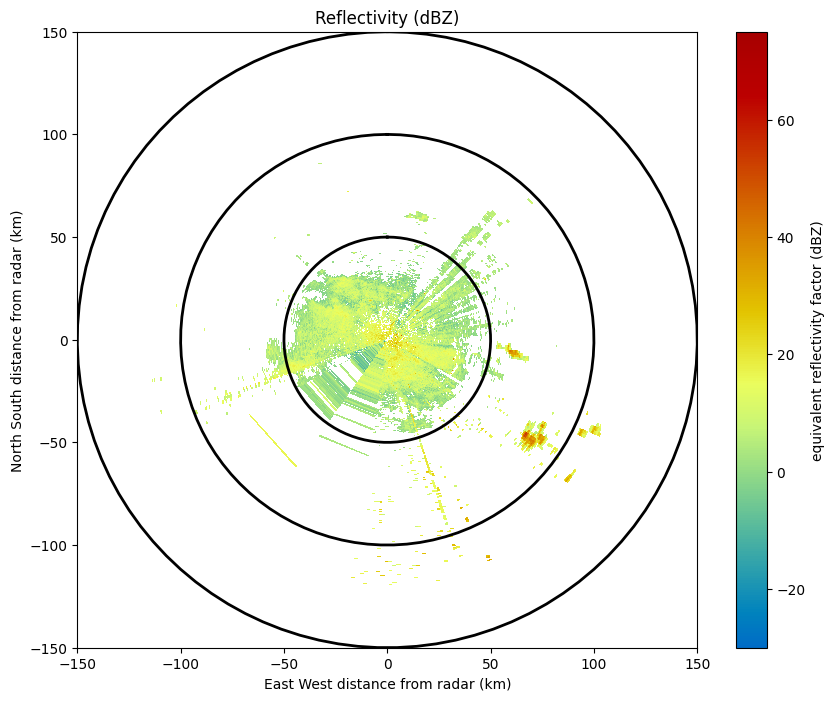

In [ ]:
# Create a display object for the radar data
display = pyart.graph.RadarDisplay(radar)
# Plot reflectivity data
fig = plt.figure(figsize=[10, 8])
ax = fig.add_subplot(111)
display.plot('reflectivity', 0, ax=ax, title='Reflectivity (dBZ)')
display.set_limits(xlim=(-150, 150), ylim=(-150, 150), ax=ax)

# Display range rings at 50-km intervals
display.plot_range_rings([50, 100, 150])

# Show the plot
plt.show()

# 3.Issues and Concerns

**Relevance to Our Topic:**

- “How to integrate data from multiple sources”. When doing data integration, we should not only care about how to do schema and semantic mapping, but also take in mind the task of managing our system as a whole.
- How to scale up our topics of data.

**Data Quality:** How to know our data are quality. If not, how to determine our data have missing values, outliers, or inconsistencies.

**Data Preprocessing Needs:** Highlight any necessary data cleaning, transformation, or standardization steps.

**Data Limitations:** Should we consider optimizing data storage, or optimizing lookup convention/speed.



# 4.Additional Data Requirements

**Data Variables:** Specify if there are specific variables or attributes required for our analysis that are not present in the dataset.

**Data Sources:** Identify potential additional data sources that may complement or enhance our analysis.

**Data Access:** Check if there are any restrictions on data access or licensing issues.


# 5.Conclusion

Summarize the key takeaways from your analysis of the dataset, including any action items for the team.

By following this template, each team can provide a concise and informative report on the datasets, ensuring a clear understanding and readiness for further analysis. Please make sure to replace the placeholders in square brackets with the actual dataset and project-specific information.

# 6.Next Step

## 6.1.Product Description


The Weather Data Platform (WDP), is designed to be a comprehensive solution for harnessing the power of weather data. It caters to the specific needs of meteorologists, scholars, academic researchers, and developers from various sectors, including freelancers, businesses, and non-governmental organizations (NGOs). The WDP serves as a centralized hub for weather data integration, analytics, and much more.

## 6.2.Motivation

- The need to understand client requirements and translate them into product features.
- Adopting software development life cycle (SDLC) methodologies, such as Agile, to efficiently develop and deliver the product.
- Distinguishing between core and extended features.
- Deciding whether the product should have fixed or scalable capabilities.
- Building a platform that integrates weather data, analytics, and various other data sources.

## 6.3.Functional Requirements

Functional requirements outline the specific features and capabilities your product should have. In the context of your weather data platform, these might include:

- Data ingestion from various sources (e.g., weather APIs, government weather data).
- Data storage, including the creation of a data warehouse or data lake.
- Data analytics and visualization tools for meteorologists and researchers.
- Integration with external platforms and APIs.
- User management and access control.
- Reporting and alerting features.

## 6.4.Non-Functional Requirements

Non-functional requirements focus on qualities or characteristics of the system, such as performance, security, and scalability. For your project, non-functional requirements might include:

- **Reliability:** Ensure the platform is available and performs consistently.
- **Trustworthiness:** Data integrity, security, and privacy are critical.
- **Scalability:** The ability to handle increasing data loads.
- **Performance:** Fast data processing and analytics.
- **Usability:** Intuitive user interfaces for various user groups.
- **Security:** Data protection and access control.
- **Compliance:** Adherence to data privacy and regulatory standards.

## 6.5.Data Requirements

- Data sources must be clearly defined, encompassing real-time APIs, government archives, and more.
Different data formats, including structured (JSON, XML) and unstructured (images, text reports), should be considered.
- Data acquisition methods, protocols, and update frequencies play a critical role in data quality and timeliness.
- Transformation processes, including data cleansing, normalization, and enrichment, are essential for accurate and consistent data.
- The choice between a data warehouse or data lake has a significant impact on the product's architecture and performance.
- Data lifecycle management, including retention policies and archiving, ensures efficient data storage and retrieval over time.
- Understanding these data requirements is essential for building a robust and reliable weather data product.

## 6.6.Use Case Scenarios

List scenarios that describe how different user groups will interact with the platform. This can include tasks like data exploration, querying, visualization, data export, and reporting. Consider the unique needs and priorities of meteorologists, scholars, academic researchers, and developers in these scenarios.

Other Relevant Terms:

- **Agile:** Mention how Agile methodologies will be applied to ensure flexibility and adaptability throughout the project.
- **SDLC (Software Development Life Cycle):** Describe the stages of the development process, such as planning, design, development, testing, and deployment.
- **APIs:** Specify the external APIs or services that will be integrated into the platform.
- **Product Features:** Distinguish between core features necessary for the platform's core functionality and extended features that enhance its capabilities.
- **Fixed vs. Scalable:** Decide whether the platform's architecture should be designed to accommodate a fixed, defined user base or be scalable to handle varying levels of demand.

Ensure that all these components are thoroughly documented and communicated to your development team and stakeholders. This will help you build a robust and successful weather data platform.


# 7.Cleanup

In [ ]:
drive.flush_and_unmount()

# Reference
[1] Py-ART 1.16.1.post5 documentation, https://arm-doe.github.io/pyart/API/generated/pyart.io.write_uf.html
